In [4]:
import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, retrieval_success

rng = np.random.default_rng(0)

n_neurons = 2000
sparsity = 0.1

print(f"N_neurons = {n_neurons}, sparsity p = {sparsity}")

N_neurons = 2000, sparsity p = 0.1


In [3]:
def build_network_with_memories(n_neurons, sparsity, n_old, rng, sequential=True):
    """Construct a network with n_old old memories, then fear and extinction.

    Returns
    -------
    net : HopfieldNetwork
    old_patterns : list[np.ndarray]
    fear_pattern : np.ndarray
    ext_pattern : np.ndarray
    storage_mode : str
        'sequential' or 'parallel'
    """
    net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)

    # generate all patterns first so sequential vs parallel see same set
    all_patterns = [generate_sparse_pattern(n_neurons, sparsity, rng=rng) for _ in range(n_old + 2)]
    old_patterns = all_patterns[:n_old]
    fear_pattern = all_patterns[n_old]
    ext_pattern = all_patterns[n_old + 1]

    if sequential:
        # store old, then fear, then extinction sequentially
        for p in old_patterns:
            net.store_pattern_sequential(p)
        net.store_pattern_sequential(fear_pattern)
        net.store_pattern_sequential(ext_pattern)
        storage_mode = "sequential"
    else:
        # parallel: all-at-once
        net.store_patterns(old_patterns + [fear_pattern, ext_pattern])
        storage_mode = "parallel"

    return net, old_patterns, fear_pattern, ext_pattern, storage_mode


def retrieve_overlap(net, pattern):
    final_state, traj, energies = net.run(
        initial_state=pattern,
        external_input=None,
        beta=1.0,
        theta=0.0,
        max_steps=50,
        asynchronous=False,
    )
    return pattern_overlap(final_state, pattern)

In [4]:
# Sweep number of old memories and examine retrieval quality

n_old_list = np.arange(0, 201, 20)  # 0,20,...,200 old memories

results_seq = {"n_old": [], "fear": [], "ext": [], "old_mean": [], "old_min": []}
results_par = {"n_old": [], "fear": [], "ext": [], "old_mean": [], "old_min": []}

for n_old in n_old_list:
    # use separate RNGs so sequential/parallel each see their own random draw,
    # but are internally consistent across n_old
    rng_seq = np.random.default_rng(1234 + n_old)
    rng_par = np.random.default_rng(2234 + n_old)

    # sequential storage
    net_s, old_s, fear_s, ext_s, _ = build_network_with_memories(
        n_neurons, sparsity, n_old, rng_seq, sequential=True
    )
    fear_ov_s = retrieve_overlap(net_s, fear_s)
    ext_ov_s = retrieve_overlap(net_s, ext_s)
    old_ovs_s = [retrieve_overlap(net_s, p) for p in old_s] if n_old > 0 else []

    results_seq["n_old"].append(n_old)
    results_seq["fear"].append(fear_ov_s)
    results_seq["ext"].append(ext_ov_s)
    results_seq["old_mean"].append(np.mean(old_ovs_s) if old_ovs_s else np.nan)
    results_seq["old_min"].append(np.min(old_ovs_s) if old_ovs_s else np.nan)

    # parallel storage
    net_p, old_p, fear_p, ext_p, _ = build_network_with_memories(
        n_neurons, sparsity, n_old, rng_par, sequential=False
    )
    fear_ov_p = retrieve_overlap(net_p, fear_p)
    ext_ov_p = retrieve_overlap(net_p, ext_p)
    old_ovs_p = [retrieve_overlap(net_p, p) for p in old_p] if n_old > 0 else []

    results_par["n_old"].append(n_old)
    results_par["fear"].append(fear_ov_p)
    results_par["ext"].append(ext_ov_p)
    results_par["old_mean"].append(np.mean(old_ovs_p) if old_ovs_p else np.nan)
    results_par["old_min"].append(np.min(old_ovs_p) if old_ovs_p else np.nan)

results_seq, results_par

({'n_old': [np.int64(0),
   np.int64(20),
   np.int64(40),
   np.int64(60),
   np.int64(80),
   np.int64(100),
   np.int64(120),
   np.int64(140),
   np.int64(160),
   np.int64(180),
   np.int64(200)],
  'fear': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.825),
   np.float64(0.81),
   np.float64(0.785),
   np.float64(0.875),
   np.float64(0.88),
   np.float64(0.86),
   np.float64(0.865),
   np.float64(0.785)],
  'ext': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.965),
   np.float64(0.905),
   np.float64(0.84),
   np.float64(0.86),
   np.float64(0.835),
   np.float64(0.82),
   np.float64(0.785),
   np.float64(0.78)],
  'old_mean': [nan,
   np.float64(1.0),
   np.float64(0.993375),
   np.float64(0.8845833333333334),
   np.float64(0.834125),
   np.float64(0.8242499999999999),
   np.float64(0.8112083333333333),
   np.float64(0.8290714285714286),
   np.float64(0.8280000000000001),
   np.float64(0.8216666666666665),
   np.float64(0.

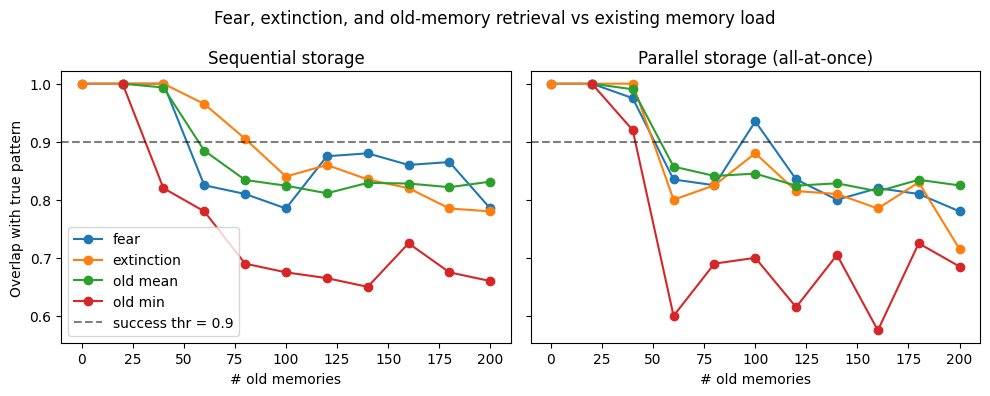

In [5]:
# Plot overlaps as a function of number of old memories

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(results_seq["n_old"], results_seq["fear"], "o-", label="fear")
axes[0].plot(results_seq["n_old"], results_seq["ext"], "o-", label="extinction")
axes[0].plot(results_seq["n_old"], results_seq["old_mean"], "o-", label="old mean")
axes[0].plot(results_seq["n_old"], results_seq["old_min"], "o-", label="old min")
axes[0].axhline(0.9, color="k", linestyle="--", alpha=0.5, label="success thr = 0.9")
axes[0].set_title("Sequential storage")
axes[0].set_xlabel("# old memories")
axes[0].set_ylabel("Overlap with true pattern")
axes[0].legend(loc="best")

axes[1].plot(results_par["n_old"], results_par["fear"], "o-", label="fear")
axes[1].plot(results_par["n_old"], results_par["ext"], "o-", label="extinction")
axes[1].plot(results_par["n_old"], results_par["old_mean"], "o-", label="old mean")
axes[1].plot(results_par["n_old"], results_par["old_min"], "o-", label="old min")
axes[1].axhline(0.9, color="k", linestyle="--", alpha=0.5, label="success thr = 0.9")
axes[1].set_title("Parallel storage (all-at-once)")
axes[1].set_xlabel("# old memories")

plt.suptitle("Fear, extinction, and old-memory retrieval vs existing memory load")
plt.tight_layout()
plt.show()

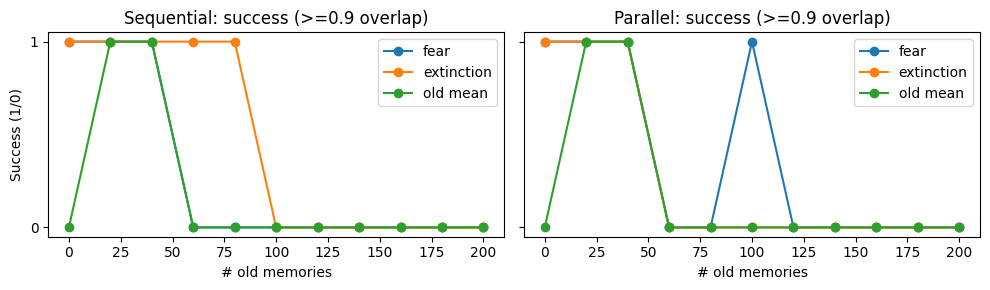

In [6]:
# Optional: convert overlaps into retrieval success (overlap >= 0.9)

seq_fear_succ = np.array(results_seq["fear"]) >= 0.9
seq_ext_succ = np.array(results_seq["ext"]) >= 0.9
seq_old_mean_succ = np.array(results_seq["old_mean"]) >= 0.9

par_fear_succ = np.array(results_par["fear"]) >= 0.9
par_ext_succ = np.array(results_par["ext"]) >= 0.9
par_old_mean_succ = np.array(results_par["old_mean"]) >= 0.9

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

axes[0].plot(results_seq["n_old"], seq_fear_succ.astype(float), "o-", label="fear")
axes[0].plot(results_seq["n_old"], seq_ext_succ.astype(float), "o-", label="extinction")
axes[0].plot(results_seq["n_old"], seq_old_mean_succ.astype(float), "o-", label="old mean")
axes[0].set_title("Sequential: success (>=0.9 overlap)")
axes[0].set_xlabel("# old memories")
axes[0].set_ylabel("Success (1/0)")
axes[0].set_yticks([0, 1])
axes[0].legend(loc="best")

axes[1].plot(results_par["n_old"], par_fear_succ.astype(float), "o-", label="fear")
axes[1].plot(results_par["n_old"], par_ext_succ.astype(float), "o-", label="extinction")
axes[1].plot(results_par["n_old"], par_old_mean_succ.astype(float), "o-", label="old mean")
axes[1].set_title("Parallel: success (>=0.9 overlap)")
axes[1].set_xlabel("# old memories")
axes[1].set_yticks([0, 1])
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [5]:
# Verify batch vs sequential storage produce the same weight matrix
from engram.metrics import weight_matrix_difference

P = 50
rng = np.random.default_rng(42)

patterns = [generate_sparse_pattern(n_neurons, sparsity, rng=rng) for _ in range(P)]

net_batch = HopfieldNetwork(n_neurons, sparsity)
net_batch.store_patterns(patterns)

net_seq = HopfieldNetwork(n_neurons, sparsity)
for p in patterns:
    net_seq.store_pattern_sequential(p)

diff = weight_matrix_difference(net_batch.W, net_seq.W)
print(f"Frobenius relative difference (sequential vs batch): {diff:.2e}")
if diff >= 1e-10:
    print("Warning: relative difference >= 1e-10 (batch vs sequential weights may differ).")


Frobenius relative difference (sequential vs batch): 1.14e-15


## Notes for interpretation

- The left/right panels compare **sequential vs parallel storage** (Dan's question about how memories are added).
- Lines show overlaps for **fear**, **extinction**, and **old memories** as you increase the number of pre-existing memories.
- Look for the point where curves drop below the 0.9 line: that’s the empirical **capacity/crash** for these parameters \(N_\text{neurons}, p\).
- You can change `n_neurons`, `sparsity`, and the `n_old_list` range at the top to explore other regimes.

In [8]:
# CS-like biased external input that preferentially targets one engram

def generate_biased_cs(
    pattern: np.ndarray,
    total_fraction: float,
    within_pattern_fraction: float,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Generate a CS that activates a fixed total fraction of neurons,
    with a biased share of those active neurons coming from one engram.

    Parameters
    ----------
    pattern : np.ndarray
        Binary engram pattern to bias towards.
    total_fraction : float
        Fraction of all neurons that should be active in the CS (e.g. 0.2).
    within_pattern_fraction : float
        Fraction of active CS neurons that should lie within the engram's
        active cells (e.g. 0.5 means half of the active CS bits are on
        engram neurons, half on other neurons).
    rng : np.random.Generator | None
        Random number generator.
    """
    if rng is None:
        rng = np.random.default_rng()

    n = pattern.size
    n_total_active = int(round(total_fraction * n))
    n_total_active = max(0, min(n, n_total_active))

    cs = np.zeros_like(pattern)
    if n_total_active == 0:
        return cs

    engram_idx = np.where(pattern == 1)[0]
    non_engram_idx = np.where(pattern == 0)[0]

    # how many of the active CS neurons should be on engram cells
    n_engram_cs = int(round(within_pattern_fraction * n_total_active))
    n_engram_cs = min(n_engram_cs, engram_idx.size)

    n_non_engram_cs = n_total_active - n_engram_cs
    n_non_engram_cs = min(n_non_engram_cs, non_engram_idx.size)

    if n_engram_cs > 0:
        chosen_engram = rng.choice(engram_idx, size=n_engram_cs, replace=False)
        cs[chosen_engram] = 1

    if n_non_engram_cs > 0:
        chosen_non = rng.choice(non_engram_idx, size=n_non_engram_cs, replace=False)
        cs[chosen_non] = 1

    return cs


def retrieve_with_cs(net, target_pattern, cs_input, beta=2.0, theta=0.0, max_steps=50):
    """Run dynamics starting from the CS input and measure overlap with a target pattern."""
    init_state = cs_input.copy()  # start from CS-driven activity
    final_state, traj, energies = net.run(
        initial_state=init_state,
        external_input=cs_input,
        beta=beta,
        theta=theta,
        max_steps=max_steps,
        asynchronous=False,
    )
    return pattern_overlap(final_state, target_pattern)

In [9]:
# CS-driven retrieval: fear-biased cue vs old memories under sequential storage

cs_total_fraction = 0.2          # total fraction of neurons active in CS
cs_within_fear_fraction = 0.5    # half of CS-active neurons come from fear engram
beta_cs = 2.0                    # stronger CS drive than default

n_old_list_cs = np.arange(0, 201, 20)

cs_results_seq = {"n_old": [], "fear": [], "ext": [], "old_mean": [], "old_min": []}

for n_old in n_old_list_cs:
    rng_build = np.random.default_rng(5000 + n_old)
    rng_cs = np.random.default_rng(6000 + n_old)

    # build network with old + fear + extinction (sequential)
    net_s, old_s, fear_s, ext_s, _ = build_network_with_memories(
        n_neurons, sparsity, n_old, rng_build, sequential=True
    )

    # CS that is biased onto the fear engram
    cs_fear = generate_biased_cs(
        fear_s,
        total_fraction=cs_total_fraction,
        within_pattern_fraction=cs_within_fear_fraction,
        rng=rng_cs,
    )

    # retrieval overlaps starting from fear-biased CS
    fear_ov = retrieve_with_cs(net_s, fear_s, cs_fear, beta=beta_cs)
    ext_ov = retrieve_with_cs(net_s, ext_s, cs_fear, beta=beta_cs)
    old_ovs = [retrieve_with_cs(net_s, p, cs_fear, beta=beta_cs) for p in old_s] if n_old > 0 else []

    cs_results_seq["n_old"].append(n_old)
    cs_results_seq["fear"].append(fear_ov)
    cs_results_seq["ext"].append(ext_ov)
    cs_results_seq["old_mean"].append(np.mean(old_ovs) if old_ovs else np.nan)
    cs_results_seq["old_min"].append(np.min(old_ovs) if old_ovs else np.nan)

cs_results_seq

{'n_old': [np.int64(0),
  np.int64(20),
  np.int64(40),
  np.int64(60),
  np.int64(80),
  np.int64(100),
  np.int64(120),
  np.int64(140),
  np.int64(160),
  np.int64(180),
  np.int64(200)],
 'fear': [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 'ext': [np.float64(0.165),
  np.float64(0.365),
  np.float64(0.495),
  np.float64(0.575),
  np.float64(0.435),
  np.float64(0.665),
  np.float64(0.72),
  np.float64(0.505),
  np.float64(0.725),
  np.float64(0.48),
  np.float64(0.6)],
 'old_mean': [nan,
  np.float64(0.397),
  np.float64(0.510375),
  np.float64(0.5331666666666667),
  np.float64(0.5313125000000001),
  np.float64(0.5226999999999999),
  np.float64(0.513125),
  np.float64(0.53125),
  np.float64(0.5122500000000001),
  np.float64(0.5118333333333334),
  np.float64(0.51275)],
 'old_min': [nan,
  np.float64(0.265),
  np.float64

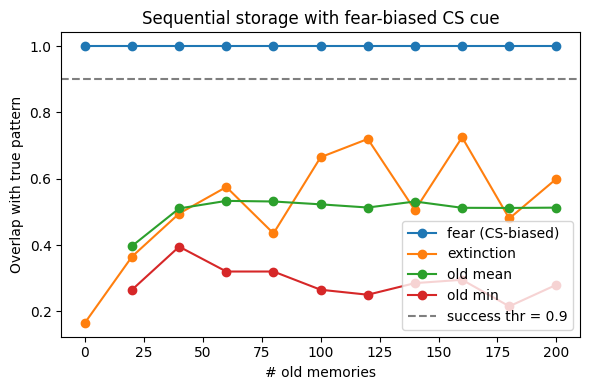

In [10]:
# Plot CS-driven retrieval: fear-biased CS vs fear, extinction, and old memories

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(cs_results_seq["n_old"], cs_results_seq["fear"], "o-", label="fear (CS-biased)")
ax.plot(cs_results_seq["n_old"], cs_results_seq["ext"], "o-", label="extinction")
ax.plot(cs_results_seq["n_old"], cs_results_seq["old_mean"], "o-", label="old mean")
ax.plot(cs_results_seq["n_old"], cs_results_seq["old_min"], "o-", label="old min")

ax.axhline(0.9, color="k", linestyle="--", alpha=0.5, label="success thr = 0.9")
ax.set_xlabel("# old memories")
ax.set_ylabel("Overlap with true pattern")
ax.set_title("Sequential storage with fear-biased CS cue")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, retrieval_success

rng = np.random.default_rng(0)

n_neurons = 2000
sparsity = 0.1
n_old = 50

# 1) initialize network with many old memories
net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
old_patterns = [generate_sparse_pattern(n_neurons, sparsity, rng=rng) for _ in range(n_old)]
for p in old_patterns:
    net.store_pattern_sequential(p)

# 2) learn fear memory
fear_pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
net.store_pattern_sequential(fear_pattern)

# 3) learn extinction memory
ext_pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
net.store_pattern_sequential(ext_pattern)

def retrieve_overlap(net, pattern):
    final_state, traj, energies = net.run(
        initial_state=pattern,
        external_input=None,
        beta=1.0,
        theta=0.0,
        max_steps=50,
        asynchronous=False,
    )
    return pattern_overlap(final_state, pattern)

fear_ov = retrieve_overlap(net, fear_pattern)
ext_ov = retrieve_overlap(net, ext_pattern)
old_ovs = [retrieve_overlap(net, p) for p in old_patterns]

print("Fear overlap:", fear_ov)
print("Extinction overlap:", ext_ov)
print("Old memories: mean, min:", np.mean(old_ovs), np.min(old_ovs))

Fear overlap: 1.0
Extinction overlap: 0.88
Old memories: mean, min: 0.9406 0.73


## Interference Profile: Target Memory vs Load

Sweep the number of stored patterns (load) and measure how retrieval of a **target** memory (pattern 0) degrades: overlap with the target vs mean/min overlap with other stored patterns, and final activity level.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern

# Parameters: fixed target (pattern 0); pre-generate max load so the target is shared across all n_old
N = 2000
sparsity = 0.1
seed = 42
target_pattern_index = 0
n_old_values = [0, 10, 25, 50, 75, 100, 125, 150, 400]

rng = np.random.default_rng(seed)
max_P = max(n_old_values) + 1
patterns_bank = [generate_sparse_pattern(N, sparsity, rng=rng) for _ in range(max_P)]

target_overlap_list = []
mean_other_overlap_list = []
min_other_overlap_list = []
activity_fraction_list = []
n_steps_list = []

for n_old in n_old_values:
    patterns = patterns_bank[: n_old + 1]
    all_patterns = np.stack(patterns, axis=0)  # (P, N)

    net = HopfieldNetwork(n_neurons=N, sparsity=sparsity)
    net.store_patterns(patterns)

    target = patterns[target_pattern_index]
    final_state, overlap_vector, activity_trajectory, n_steps = net.retrieve_and_diagnose(
        cue_state=target,
        all_patterns=all_patterns,
        external_input=None,
        beta=0.0,
        max_steps=100,
        asynchronous=False,
    )

    target_overlap_list.append(float(overlap_vector[target_pattern_index]))
    if len(overlap_vector) > 1:
        other = np.delete(overlap_vector, target_pattern_index)
        mean_other_overlap_list.append(float(np.mean(other)))
        min_other_overlap_list.append(float(np.min(other)))
    else:
        mean_other_overlap_list.append(np.nan)
        min_other_overlap_list.append(np.nan)
    activity_fraction_list.append(activity_trajectory[-1])
    n_steps_list.append(n_steps)


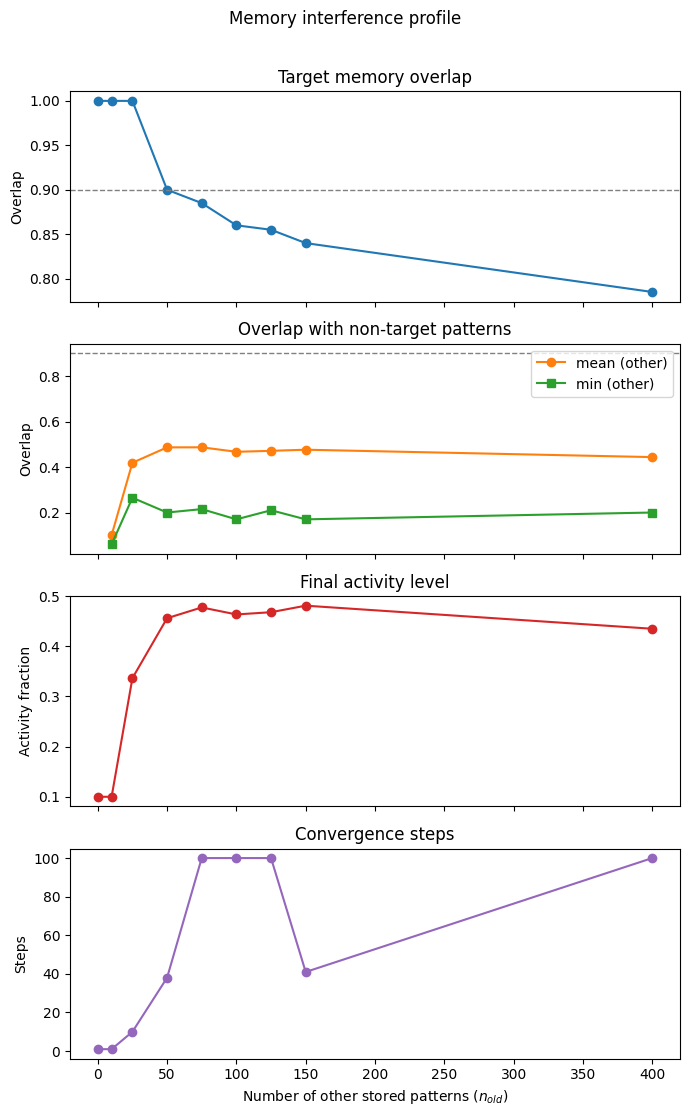

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(7, 11), sharex=True)

axes[0].plot(n_old_values, target_overlap_list, "o-", color="C0")
axes[0].axhline(0.9, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("Overlap")
axes[0].set_title("Target memory overlap")

axes[1].plot(n_old_values, mean_other_overlap_list, "o-", label="mean (other)", color="C1")
axes[1].plot(n_old_values, min_other_overlap_list, "s-", label="min (other)", color="C2")
axes[1].axhline(0.9, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("Overlap")
axes[1].legend(loc="best")
axes[1].set_title("Overlap with non-target patterns")

axes[2].plot(n_old_values, activity_fraction_list, "o-", color="C3")
axes[2].set_ylabel("Activity fraction")
axes[2].set_title("Final activity level")

axes[3].plot(n_old_values, n_steps_list, "o-", color="C4")
axes[3].set_xlabel("Number of other stored patterns ($n_{old}$)")
axes[3].set_ylabel("Steps")
axes[3].set_title("Convergence steps")

fig.suptitle("Memory interference profile", y=1.01)
fig.tight_layout()
plt.show()


## Retrospective Interference Profile: Recent Memory vs Prior Load

Use the same load sweep and metrics as the prospective profile, but now cue retrieval with the **most recently stored** pattern and evaluate overlap with **previously stored** patterns.


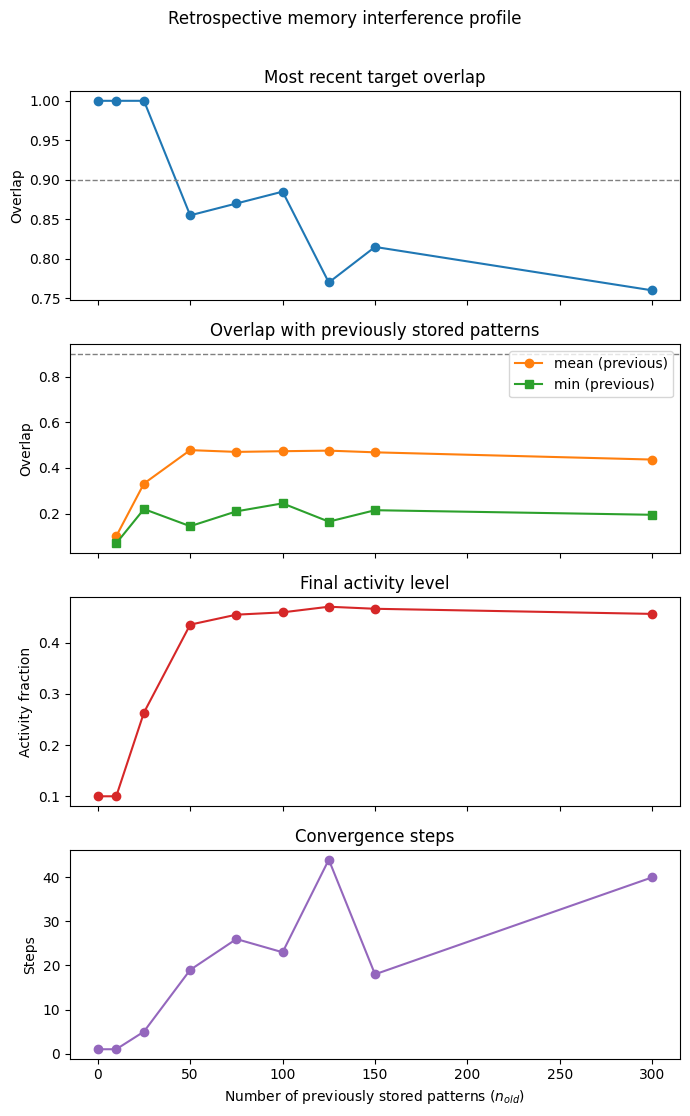

In [ ]:
# Retrospective profile: newest target vs previously stored memories
N = 2000
sparsity = 0.1
seed = 42
n_old_values = [0, 10, 25, 50, 75, 100, 125, 150, 300]

rng = np.random.default_rng(seed)
max_P = max(n_old_values) + 1
patterns_bank = [generate_sparse_pattern(N, sparsity, rng=rng) for _ in range(max_P)]

recent_target_overlap_list = []
mean_previous_overlap_list = []
min_previous_overlap_list = []
ret_activity_fraction_list = []
ret_n_steps_list = []

for n_old in n_old_values:
    patterns = patterns_bank[: n_old + 1]
    all_patterns = np.stack(patterns, axis=0)

    net = HopfieldNetwork(n_neurons=N, sparsity=sparsity)
    net.store_patterns(patterns)

    recent_target = patterns[-1]
    _final_state, overlap_vector, activity_trajectory, n_steps = net.retrieve_and_diagnose(
        cue_state=recent_target,
        all_patterns=all_patterns,
        external_input=None,
        beta=0.0,
        max_steps=100,
        asynchronous=True,
    )

    recent_target_overlap_list.append(float(overlap_vector[-1]))
    if len(overlap_vector) > 1:
        previous = overlap_vector[:-1]
        mean_previous_overlap_list.append(float(np.mean(previous)))
        min_previous_overlap_list.append(float(np.min(previous)))
    else:
        mean_previous_overlap_list.append(np.nan)
        min_previous_overlap_list.append(np.nan)

    ret_activity_fraction_list.append(activity_trajectory[-1])
    ret_n_steps_list.append(n_steps)

fig, axes = plt.subplots(4, 1, figsize=(7, 11), sharex=True)

axes[0].plot(n_old_values, recent_target_overlap_list, "o-", color="C0")
axes[0].axhline(0.9, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("Overlap")
axes[0].set_title("Most recent target overlap")

axes[1].plot(n_old_values, mean_previous_overlap_list, "o-", label="mean (previous)", color="C1")
axes[1].plot(n_old_values, min_previous_overlap_list, "s-", label="min (previous)", color="C2")
axes[1].axhline(0.9, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("Overlap")
axes[1].legend(loc="best")
axes[1].set_title("Overlap with previously stored patterns")

axes[2].plot(n_old_values, ret_activity_fraction_list, "o-", color="C3")
axes[2].set_ylabel("Activity fraction")
axes[2].set_title("Final activity level")

axes[3].plot(n_old_values, ret_n_steps_list, "o-", color="C4")
axes[3].set_xlabel("Number of previously stored patterns ($n_{old}$)")
axes[3].set_ylabel("Steps")
axes[3].set_title("Convergence steps")

fig.suptitle("Retrospective memory interference profile", y=1.01)
fig.tight_layout()
plt.show()
